In [1]:
# Usual imports
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from rich.progress import Progress
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# RobustBench
import robustbench
from robustbench.utils import load_model
from secml.utils import fm
from secml import settings


2026-06-15 15:23:43.208401: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-15 15:23:43.561037: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-15 15:23:46.238116: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## CUDA

In [2]:
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA available: True
GPU name: NVIDIA GeForce RTX 4090


## Utilities

In [3]:
class ProbRegressionWrapper(nn.Module):
    def __init__(self, classifier):
        super().__init__()
        self.classifier = classifier  # pretrained classifier

    def forward(self, x):
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=1)
        return probs
    
def load_cifar10_splits(
    n_train=1000,
    n_cal=500,
    n_test=2000
):
    transform = T.ToTensor()

    # Load datasets
    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )

    # Random selection (only indices)
    perm_train = torch.randperm(len(trainset))

    idx_train = perm_train[:n_train]
    idx_cal = perm_train[n_train:n_train+n_cal]
    idx_test = perm_train[:n_test]

    # Extract only needed samples (NO full dataset stacking)
    X_train = torch.stack([trainset[i][0] for i in idx_train])
    y_train = torch.tensor([trainset[i][1] for i in idx_train])

    X_cal = torch.stack([trainset[i][0] for i in idx_cal])
    y_cal = torch.tensor([trainset[i][1] for i in idx_cal])

    X_test = torch.stack([trainset[i][0] for i in idx_test])
    y_test = torch.tensor([trainset[i][1] for i in idx_test])

    return (X_train, y_train), (X_cal, y_cal), (X_test, y_test)

## Dataset

### CIFAR_10

In [4]:
(train_X, train_y), (cal_X, cal_y), (test_X, test_y) = load_cifar10_splits(
    n_train=100, n_cal=500, n_test=1000
)

train_X = train_X.to(device)
train_y = train_y.to(device)

cal_X = cal_X.to(device)
cal_y = cal_y.to(device)

test_X = test_X.to(device)
test_y = test_y.to(device)

### One-hot encode 
#### (from classification to regression)

In [5]:
num_classes = 10
train_y_oh = F.one_hot(train_y, num_classes=num_classes).float()
cal_y_oh = F.one_hot(cal_y, num_classes=num_classes).float()
test_y_oh = F.one_hot(test_y, num_classes=num_classes).float()

## RobustBench

### Regression on Correct-Class Probability

We treat the pretrained classification model as a regressor on the **true-class probability**.  
The regression target is the logit of the true class probability:


$$ y_{\text{reg}} = \text{logit}\big(p_{\text{true class}}(x)\big) = \log \frac{p_{\text{true class}}(x)}{1 - p_{\text{true class}}(x)} $$ 


The regressor $ g_\phi(x) $ predicts this real value:

$$
\hat{y}_{\text{reg}} = g_\phi(x) \approx y_{\text{reg}}
$$

Performance can be evaluated using MSE on the predicted correct-class probability, classification accuracy, and calibration metrics.


In [6]:
#L2#
#Wang2023Better_WRN-70-16

#Linf#
#Andriushchenko2020Understanding

In [7]:
output_dir = fm.join(settings.SECML_MODELS_DIR, 'robustbench')

### Load a model

In [8]:
def load_rb_model(model_name, device, norm = 'L2', model_dir="./models"):
    model = load_model(model_name, norm=norm, model_dir=model_dir).to(device)
    return model

In [9]:
# L2
model_names = [
    #"Wang2023Better_WRN-70-16",
    #"Rebuffi2021Fixing_70_16_cutmix_extra",  
    #"Amini2024MeanSparse_S-WRN-70-16",  
    #"Augustin2020Adversarial",  
    "Wu2020Adversarial" 
]

In [10]:
models = {}

for name in model_names:
    print(f"Loading {name}...")
    mdl = load_rb_model(name, 'cuda','L2', model_dir=output_dir)
    models[name] = ProbRegressionWrapper(mdl)

print("\nLoaded models:")
print(list(models.keys()))


Loading Wu2020Adversarial...

Loaded models:
['Wu2020Adversarial']


In [11]:
reg_wu = models["Wu2020Adversarial"]

In [12]:
def get_correct_probs(model, X, y):
    with torch.no_grad():
        probs = model(X)                # shape: (n, 10)
        correct_probs = probs[range(len(y)), y]  # shape: (n,)
    return correct_probs.to(device)

### Evaluate the model

In [16]:
def evaluate_model_probs(model, X, y, device, batch_size=128):
    """
    Compute probabilities, correct-class probs, MSE, accuracy for a model.
    """
    model.eval()
    all_probs = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = X[i:i + batch_size].to(device)
            p = model(batch)  # (batch, 10)
            all_probs.append(p)

    probs = torch.cat(all_probs, dim=0)          # (n_samples, 10)
    correct_probs = probs[range(len(y)), y]      # (n_samples,)

    mse = ((correct_probs - 1) ** 2).mean().item()

    preds = probs.argmax(dim=1)
    acc = (preds == y).float().mean().item()

    return probs, correct_probs, mse, acc


========== Evaluating model: Wu2020Adversarial ==========
MSE: 0.052295
Accuracy: 98.20%


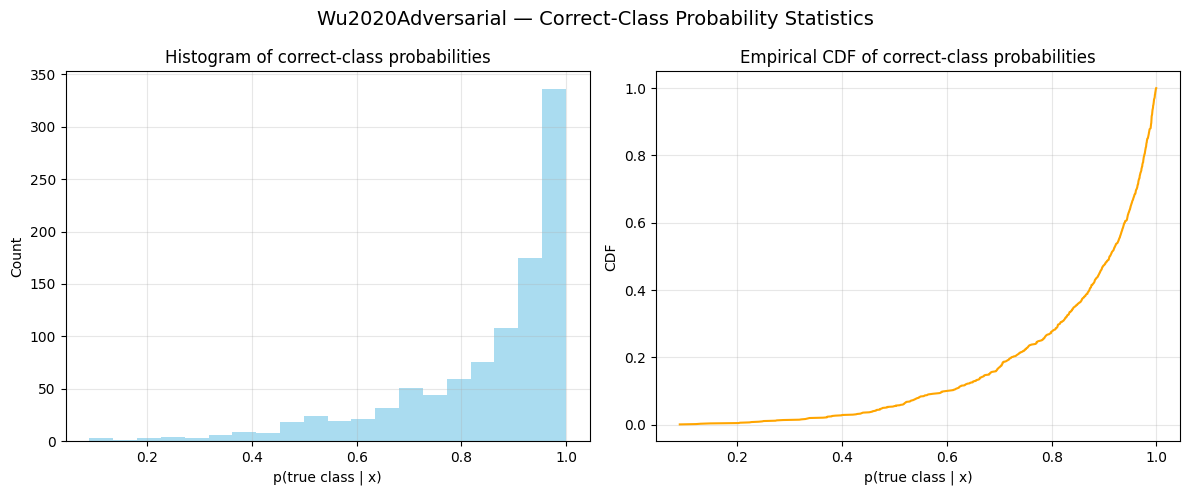

In [17]:
for name, model in models.items():
    print(f"\n========== Evaluating model: {name} ==========")
    probs, correct_probs, mse, acc = evaluate_model_probs(model, test_X, test_y, device)

    print(f"MSE: {mse:.6f}")
    print(f"Accuracy: {acc*100:.2f}%")

    # ----------------------------
    # Plots: Histogram + CDF
    # ----------------------------
    plt.figure(figsize=(12, 5))
    plt.suptitle(f"{name} — Correct-Class Probability Statistics", fontsize=14)

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(correct_probs.cpu().numpy(), bins=20, alpha=0.7, color='skyblue')
    plt.title("Histogram of correct-class probabilities")
    plt.xlabel("p(true class | x)")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # CDF
    plt.subplot(1, 2, 2)
    sorted_probs, _ = torch.sort(correct_probs.cpu())
    cdf = torch.arange(1, len(sorted_probs) + 1) / len(sorted_probs)

    plt.plot(sorted_probs.numpy(), cdf.numpy(), color='orange')
    plt.title("Empirical CDF of correct-class probabilities")
    plt.xlabel("p(true class | x)")
    plt.ylabel("CDF")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Attack

In [39]:
# pip install torchattacks
import torchattacks
from autoattack import AutoAttack

class ProbToLogitsWrapper(torch.nn.Module):
    def __init__(self, model_prob):
        super().__init__()
        self.model_prob = model_prob  # il tuo modello che restituisce probabilità

    def forward(self, x):
        probs = self.model_prob(x)           # (B, K)
        logits = torch.log(probs + 1e-12)    # conversione sicura
        return logits

def attack_with_autoattack_fast(model_prob, X, y, eps=8/255, norm='L2', bs=256, device='cuda'):
    model_prob.eval()

    # wrapper veloce
    model_for_attack = ProbToLogitsWrapper(model_prob).to(device)
    model_for_attack.eval()

    X = X.to(device)
    y = y.to(device)

    autoattack = AutoAttack(
        model_for_attack,
        norm=norm,
        eps=eps,
        version='custom',          # per avere un singolo attacco
        attacks_to_run=['apgd-ce'], 
        device=device,
        verbose=True
    )

    # riduci il numero di iterazioni
    autoattack.apgd.n_iter = 10
    
    adversarial_examples = autoattack.run_standard_evaluation(X, y, bs=bs)

    return adversarial_examples

In [25]:
cal_X_adv_aa = attack_with_autoattack(
    reg_wu, cal_X, cal_y,
    eps=8/255, norm='L2', bs=128, device=device
)

setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 98.00%
apgd-ce - 1/4 - 0 out of 128 successfully perturbed
apgd-ce - 2/4 - 0 out of 128 successfully perturbed
apgd-ce - 3/4 - 0 out of 128 successfully perturbed
apgd-ce - 4/4 - 1 out of 106 successfully perturbed
robust accuracy after APGD-CE: 97.80% (total time 28.2 s)
apgd-t - 1/4 - 0 out of 128 successfully perturbed
apgd-t - 2/4 - 0 out of 128 successfully perturbed
apgd-t - 3/4 - 0 out of 128 successfully perturbed
apgd-t - 4/4 - 0 out of 105 successfully perturbed
robust accuracy after APGD-T: 97.80% (total time 289.5 s)
fab-t - 1/4 - 0 out of 128 successfully perturbed
fab-t - 2/4 - 0 out of 128 successfully perturbed
fab-t - 3/4 - 0 out of 128 successfully perturbed
fab-t - 4/4 - 0 out of 105 successfully perturbed
robust accuracy after FAB-T: 97.80% (total time 873.0 s)
square - 1/4 - 0 out of 128 successfully perturbed
square - 2/4 - 0 out of 128 succes

In [26]:
cal_X_adv_aa

tensor([[[[0.1843, 0.2000, 0.1882,  ..., 0.1882, 0.1686, 0.1961],
          [0.1843, 0.1961, 0.1843,  ..., 0.1922, 0.1647, 0.1922],
          [0.2039, 0.2588, 0.1765,  ..., 0.2392, 0.1922, 0.1882],
          ...,
          [0.4314, 0.3922, 0.3647,  ..., 0.2824, 0.2235, 0.2902],
          [0.4157, 0.4196, 0.3647,  ..., 0.3176, 0.2588, 0.3333],
          [0.3373, 0.3529, 0.3843,  ..., 0.3137, 0.3216, 0.3333]],

         [[0.2745, 0.2902, 0.2784,  ..., 0.2784, 0.2627, 0.2902],
          [0.2745, 0.2863, 0.2745,  ..., 0.2824, 0.2627, 0.2902],
          [0.2588, 0.3176, 0.2588,  ..., 0.3059, 0.2706, 0.2745],
          ...,
          [0.4902, 0.3922, 0.3529,  ..., 0.3333, 0.3020, 0.3647],
          [0.4706, 0.4196, 0.3569,  ..., 0.3725, 0.3333, 0.4118],
          [0.3961, 0.3765, 0.3961,  ..., 0.3686, 0.4039, 0.4157]],

         [[0.1647, 0.1804, 0.1686,  ..., 0.1647, 0.1176, 0.1451],
          [0.1647, 0.1765, 0.1647,  ..., 0.1647, 0.1176, 0.1451],
          [0.1529, 0.2235, 0.1686,  ..., 0

In [18]:
def fgsm_attack_regression_batched(model, X, y, epsilon=0.05, batch_size=32):
    model.eval()
    X_adv_list = []
    
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].clone().detach().to(device)
        yb = y[i:i+batch_size].to(device)

        xb.requires_grad = True

        # Forward
        probs = model(xb)  # shape (B,10)
        correct_probs = probs[range(len(yb)), yb]

        # Loss = push correct class prob → 1
        loss = ((correct_probs - 1)**2).mean()

        # Compute gradient
        model.zero_grad()
        loss.backward()

        # FGSM step
        xb_adv = xb + epsilon * xb.grad.sign()
        xb_adv = torch.clamp(xb_adv, 0, 1).detach()

        X_adv_list.append(xb_adv)  # move OFF GPU immediately

        # Free memory
        del xb, yb, probs, correct_probs, loss, xb_adv
        torch.cuda.empty_cache()

    return torch.cat(X_adv_list, dim=0)

### Run the attack

### L2 ------ $\varepsilon = 0.5$

In [40]:
eps = 0.5   # AutoAttack tipico
batch_size = 256

adv_data = {}  # qui salviamo i risultati per ogni modello

for model_name, model in models.items():
    print(f"\n========== Generating AutoAttack adversarial data for model: {model_name} ==========")

    # calibration set
    cal_X_adv = attack_with_autoattack(
        model, cal_X, cal_y,
        eps=eps,
        norm='L2',   # o 'Linf'
        bs=batch_size,
        device=device
    )

    # test set
    test_X_adv = attack_with_autoattack(
        model, test_X, test_y,
        eps=eps,
        norm='L2',
        bs=batch_size,
        device=device
    )

    adv_data[model_name] = {
        "cal_X_adv":  cal_X_adv,
        "test_X_adv": test_X_adv
    }

print("\nDone.")


========== Generating AutoAttack adversarial data for model: Wu2020Adversarial ==========
using custom version including apgd-ce.
initial accuracy: 98.00%
apgd-ce - 1/2 - 16 out of 256 successfully perturbed
apgd-ce - 2/2 - 18 out of 234 successfully perturbed
robust accuracy after APGD-CE: 91.20% (total time 137.7 s)
max L2 perturbation: 0.50000, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 91.20%
using custom version including apgd-ce.
initial accuracy: 98.20%
apgd-ce - 1/4 - 11 out of 256 successfully perturbed
apgd-ce - 2/4 - 17 out of 256 successfully perturbed
apgd-ce - 3/4 - 24 out of 256 successfully perturbed
apgd-ce - 4/4 - 12 out of 214 successfully perturbed
robust accuracy after APGD-CE: 91.80% (total time 276.7 s)
max L2 perturbation: 0.50000, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 91.80%

Done.


### Post-attack evaluation


========== Post-attack evaluation for model: Wu2020Adversarial ==========
MSE (clean): 0.052295
MSE after attack: 0.066800
Accuracy (clean): 98.20%
Accuracy after attack: 91.90%


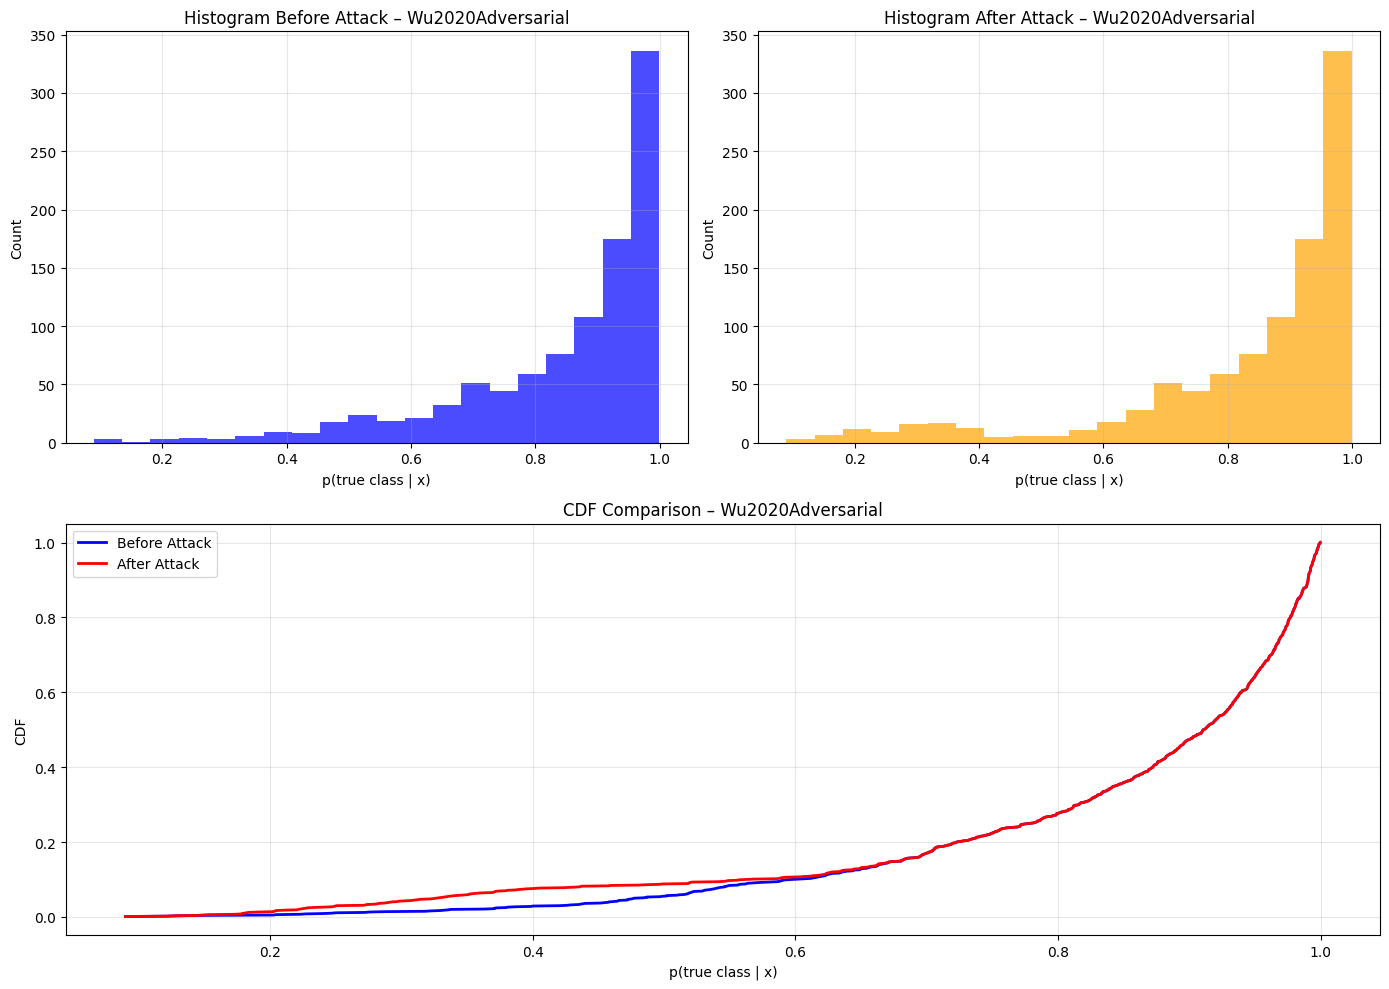

In [42]:
batch_size = 128

results_post_attack = {}

for model_name, model in models.items():
    print(f"\n========== Post-attack evaluation for model: {model_name} ==========")

    model.eval()
    test_X_adv = adv_data[model_name]["test_X_adv"]

    # -----------------------------
    # Forward pass adversarial
    # -----------------------------
    all_probs_adv = []
    with torch.no_grad():
        for i in range(0, len(test_X_adv), batch_size):
            batch = test_X_adv[i:i+batch_size].to(device)
            p = model(batch)
            all_probs_adv.append(p)

    probs_adv = torch.cat(all_probs_adv, dim=0)

    # -----------------------------
    # Pre-attack probs (calcoliamole se non le hai salvate)
    # -----------------------------
    all_probs_clean = []
    with torch.no_grad():
        for i in range(0, len(test_X), batch_size):
            batch = test_X[i:i+batch_size].to(device)
            p = model(batch)
            all_probs_clean.append(p)

    probs_clean = torch.cat(all_probs_clean, dim=0)

    # Correct class probabilities
    correct_probs_clean = probs_clean[range(len(test_y)), test_y]
    correct_probs_adv   = probs_adv[range(len(test_y)), test_y]

    # -----------------------------
    # MSE
    # -----------------------------
    mse_adv = ((correct_probs_adv - 1)**2).mean().item()
    mse_clean = ((correct_probs_clean - 1)**2).mean().item()

    print(f"MSE (clean): {mse_clean:.6f}")
    print(f"MSE after attack: {mse_adv:.6f}")

    # -----------------------------
    # Accuracy
    # -----------------------------
    preds_clean = probs_clean.argmax(dim=1)
    preds_adv   = probs_adv.argmax(dim=1)

    acc_clean = (preds_clean == test_y.to(device)).float().mean().item()
    acc_adv   = (preds_adv == test_y.to(device)).float().mean().item()

    print(f"Accuracy (clean): {acc_clean*100:.2f}%")
    print(f"Accuracy after attack: {acc_adv*100:.2f}%")

    # -----------------------------
    # Pre and Post Attack CDFs
    # -----------------------------
    sorted_probs_pre  = np.sort(correct_probs_clean.cpu().numpy())
    sorted_probs_post = np.sort(correct_probs_adv.cpu().numpy())

    cdf_pre  = np.arange(1, len(sorted_probs_pre)+1)  / len(sorted_probs_pre)
    cdf_post = np.arange(1, len(sorted_probs_post)+1) / len(sorted_probs_post)

    # -----------------------------
    # PLOT
    # -----------------------------
    fig = plt.figure(figsize=(14, 10))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1])

    # Histogram before
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.hist(correct_probs_clean.cpu().numpy(), bins=20, alpha=0.7, color='blue')
    ax0.set_title(f"Histogram Before Attack – {model_name}")
    ax0.set_xlabel("p(true class | x)")
    ax0.set_ylabel("Count")
    ax0.grid(alpha=0.3)

    # Histogram after
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.hist(correct_probs_adv.cpu().numpy(), bins=20, alpha=0.7, color='orange')
    ax1.set_title(f"Histogram After Attack – {model_name}")
    ax1.set_xlabel("p(true class | x)")
    ax1.set_ylabel("Count")
    ax1.grid(alpha=0.3)

    # CDF comparison
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(sorted_probs_pre, cdf_pre, color='blue', linewidth=2, label='Before Attack')
    ax2.plot(sorted_probs_post, cdf_post, color='red',  linewidth=2, label='After Attack')
    ax2.set_title(f"CDF Comparison – {model_name}")
    ax2.set_xlabel("p(true class | x)")
    ax2.set_ylabel("CDF")
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Save results
    results_post_attack[model_name] = {
        "mse_clean": mse_clean,
        "mse_adv": mse_adv,
        "acc_clean": acc_clean,
        "acc_adv": acc_adv,
        "correct_probs_clean": correct_probs_clean,
        "correct_probs_adv": correct_probs_adv,
    }


## CP SEI ARRIVATO QUI !!!

In [43]:
def nonconformity_score(y_true, y_pred, u=None):
    """
    Compute nonconformity scores for regression CP, optionally using an uncertainty scalar.

    Args:
        y_true: torch.Tensor of shape (n,)  -- true regression targets
        y_pred: torch.Tensor of shape (n,)  -- predicted regression outputs
        u: torch.Tensor of shape (n,), optional -- per-example uncertainty (e.g., predicted std or residual)
    
    Returns:
        scores: torch.Tensor of shape (n,)  -- nonconformity scores
    """
    residuals = torch.abs(y_pred - y_true)
    
    if u is not None:
        scores = residuals / u
        
    else:
        scores = residuals
    
    return scores


In [44]:
def cp_interval_width(u, qhat):
    """
    Computes conformal prediction interval widths.
    
    Args:
        u:    array-like of shape (n,) -- uncertainty scalar u(x)
        qhat: float                   -- conformal quantile

    Returns:
        width: array of shape (n,) -- interval widths
    """
    u = torch.as_tensor(u, dtype=torch.float32)
    return 2 * u * qhat

In [45]:
def extract_scores(models,
                   cal_X, cal_y,
                   test_X, test_y,
                   datamode="clean"):
    """
    Estrarre score, predizioni e u dal calibration e test set.
    Può lavorare sia su dati clean sia attaccati.

    Args:
        models: dict {name: model}
        cal_X, cal_y: calibration data
        test_X, test_y: test data
        datamode: "clean" oppure "adv"

    Returns:
        results: dict con per-modello:
            probs_cal, y_pred_cal, u_cal, score_cal
            probs_test, y_pred_test, u_test, score_test
    """

    results = {}

    with torch.no_grad():
        for name, model in models.items():
            print(f"\n=== Processing model: {name} ({datamode}) ===")

            # -----------------------------
            # Calibrazione
            # -----------------------------
            probs_cal = model(cal_X)
            y_pred_cal = probs_cal[range(len(cal_y)), cal_y]

            #u_cal = ((y_pred_cal - 1) ** 2)#.mean().item()
            #epsilon = 1e-6
            #u_cal = torch.sqrt((y_pred_cal - 1) ** 2 + epsilon)
            
            residuals = torch.abs(y_pred_cal - 1)  # shape (n_cal,)
            residuals_reshaped = residuals.unsqueeze(0).unsqueeze(0)  # shape (1,1,n_cal)

            # Apply a 1D average pooling with kernel size 5
            smoothed_residuals = F.avg_pool1d(residuals_reshaped, kernel_size=5, stride=1, padding=2)
            u_cal = smoothed_residuals.squeeze()
            
            score_cal = nonconformity_score(
                1.0,
                y_pred_cal.float(),
                u=u_cal
            )

            # -----------------------------
            # Test
            # -----------------------------
            probs_test = model(test_X)
            y_pred_test = probs_test[range(len(test_y)), test_y]

            #u_test = ((y_pred_test - 1) ** 2)#.mean().item()
            #u_test = torch.sqrt((y_pred_test - 1) ** 2 + epsilon)
            residuals = torch.abs(y_pred_test - 1)  # shape (n_cal,)
            residuals_reshaped = residuals.unsqueeze(0).unsqueeze(0)  # shape (1,1,n_cal)

            # Apply a 1D average pooling with kernel size 5
            smoothed_residuals = F.avg_pool1d(residuals_reshaped, kernel_size=5, stride=1, padding=2)
            u_test = smoothed_residuals.squeeze()
            
            score_test = nonconformity_score(
                1.0,
                y_pred_test.float(),
                u=u_test
            )

            # -----------------------------
            # Salvataggio
            # -----------------------------
            results[name] = {
                "probs_cal": probs_cal,
                "y_pred_cal": y_pred_cal,
                "u_cal": u_cal,
                "score_cal": score_cal,

                "probs_test": probs_test,
                "y_pred_test": y_pred_test,
                "u_test": u_test,
                "score_test": score_test,
            }

    return results


In [46]:
def plot_scores_for_all_models(results):
    
    for name, data in results.items():
        print(f"\n=== Plotting for model: {name} ===")
        
        score_cal = data["score_cal"]
        score_test = data["score_test"]

        # Convert to numpy
        score_cal_np = score_cal.cpu().numpy() if hasattr(score_cal, "cpu") else np.array(score_cal)
        score_test_np = score_test.cpu().numpy() if hasattr(score_test, "cpu") else np.array(score_test)

        # Create figure
        plt.figure(figsize=(16, 5))
        plt.suptitle(f"Nonconformity Scores – {name}", fontsize=16)

        # -------------------------
        # 1. Histogram
        # -------------------------
        plt.subplot(1, 3, 1)
        plt.hist(score_cal_np, bins=30, alpha=0.6, label="Calibration", color='blue')
        plt.hist(score_test_np, bins=30, alpha=0.6, label="Test", color='orange')
        plt.title("Histogram of Scores")
        plt.xlabel("Score")
        plt.ylabel("Frequency")
        plt.legend()

        # -------------------------
        # 2. Boxplot
        # -------------------------
        plt.subplot(1, 3, 2)
        plt.boxplot([score_cal_np, score_test_np], labels=["Calibration", "Test"])
        plt.title("Boxplot of Scores")
        plt.ylabel("Score")

        # -------------------------
        # 3. Empirical CDF
        # -------------------------
        plt.subplot(1, 3, 3)
        sorted_cal = np.sort(score_cal_np)
        sorted_test = np.sort(score_test_np)
        cdf_cal = np.arange(1, len(sorted_cal)+1) / len(sorted_cal)
        cdf_test = np.arange(1, len(sorted_test)+1) / len(sorted_test)

        plt.plot(sorted_cal, cdf_cal, label="Calibration", color='blue', linewidth=2)
        plt.plot(sorted_test, cdf_test, label="Test", color='orange', linewidth=2)

        plt.title("Empirical CDF of Scores")
        plt.xlabel("Score")
        plt.ylabel("CDF")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.tight_layout()
        plt.show()


In [47]:
def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)

def compute_cp(
    clean_results, 
    adv_results, 
    alpha=0.1, 
    cal_on='clean',   # calibrazione su 'clean' o 'adv'
    eval_on='clean'   # valutazione su 'clean' o 'adv'
):
    """
    Calcola set conformi (CP) in modo flessibile.
    
    clean_results: dizionario con score ottenuti su dati clean
    adv_results:   dizionario con score ottenuti su dati avversari
    cal_on: 'clean' o 'adv' -> dataset da usare per calibrazione
    eval_on: 'clean' o 'adv' -> dataset su cui valutare coverage
    alpha: livello di significatività per CP
    """
    
    cp_outputs = {}
    
    for name in clean_results.keys():
        print(f"\n--- CP for model: {name} | Cal on: {cal_on} | Eval on: {eval_on} ---")
        
        clean = clean_results[name]
        adv   = adv_results[name]
        
        # -----------------------------------------------------
        # STEP 1 — Scegli set di calibrazione
        # -----------------------------------------------------
        if cal_on == 'clean':
            score_cal = _to_numpy(clean["score_cal"])
            y_pred_cal = _to_numpy(clean["y_pred_cal"]).astype(np.float32)
            u_cal = _to_numpy(clean["u_cal"])
        elif cal_on == 'adv':
            score_cal = _to_numpy(adv["score_cal"])
            y_pred_cal = _to_numpy(adv["y_pred_cal"]).astype(np.float32)
            u_cal = _to_numpy(adv["u_cal"])
        else:
            raise ValueError("cal_on must be 'clean' or 'adv'")
        
        n_cal = len(score_cal)
        q_level = np.floor((n_cal + 1) * (1 - alpha)) / n_cal
        qhat = float(torch.quantile(torch.tensor(score_cal, dtype=torch.float32), float(q_level)))
        print(f" q̂ (CP): {qhat:.6f}")
        
        # -----------------------------------------------------
        # STEP 2 — Scegli set di valutazione
        # -----------------------------------------------------
        if eval_on == 'clean':
            y_pred_eval   = _to_numpy(clean["y_pred_test"]).astype(np.float32)
            u_eval = _to_numpy(clean["u_test"])
        elif eval_on == 'adv':
            y_pred_eval   = _to_numpy(adv["y_pred_test"]).astype(np.float32)
            u_eval = _to_numpy(adv["u_test"])
        else:
            raise ValueError("eval_on must be 'clean' or 'adv'")
        
        y_true_eval = np.ones_like(y_pred_eval, dtype=np.float32)
        # -----------------------------------------------------
        # STEP 3 — Costruisci intervalli CP
        # -----------------------------------------------------
        radius = qhat * u_eval
        lower  = y_pred_eval - radius
        upper  = y_pred_eval + radius
        
        coverage = float(np.mean((lower <= y_true_eval) & (y_true_eval <= upper)))
        mean_width = float(np.mean(upper - lower))
        print(f" Coverage: {coverage*100:.2f}%")
        print(f" Mean interval width: {mean_width:.6f}")
        
        cp_outputs[name] = {
            "qhat": qhat,
            "coverage": coverage,
            "mean_width": mean_width,
            "lower": lower,
            "upper": upper,
            "y_pred_eval": y_pred_eval,
            "u_eval": u_eval,
            "cal_on": cal_on,
            "eval_on": eval_on,
        }
    
    return cp_outputs


In [48]:
def compute_cp(
    clean_results, 
    adv_results, 
    alpha=0.1, 
    cal_on='clean',     # calibrazione su 'clean' o 'adv'
    eval_on='clean',    # dataset su cui calcolare coverage
    interval_on='test'  # 'test' oppure 'cal'
):
    """
    Calcola CP in modo flessibile.

    clean_results: dizionario score clean
    adv_results:   dizionario score avversari
    cal_on:        set per calibrazione ('clean' o 'adv')
    eval_on:       set per coverage ('clean' o 'adv')
    interval_on:   set su cui costruire gli intervalli ('cal' o 'test')
    """
    
    cp_outputs = {}
    
    for name in clean_results.keys():
        print(f"\n--- CP for model: {name} | Cal: {cal_on} | Eval: {eval_on} | Interval: {interval_on} ---")
        
        clean = clean_results[name]
        adv   = adv_results[name]

        # -------------------------
        # STEP 1 — Calibrazione
        # -------------------------
        source_cal = clean if cal_on=='clean' else adv

        score_cal = _to_numpy(source_cal["score_cal"])
        y_pred_cal = _to_numpy(source_cal["y_pred_cal"]).astype(np.float32)
        u_cal = _to_numpy(source_cal["u_cal"])

        n_cal = len(score_cal)
        q_level = np.floor((n_cal + 1) * (1 - alpha)) / n_cal
        qhat = float(
            torch.quantile(torch.tensor(score_cal, dtype=torch.float32), float(q_level))
        )

        print(f" q̂ (CP): {qhat:.6f}")

        # -------------------------
        # STEP 2 — Scegli set per intervalli
        # -------------------------
        if interval_on == 'test':
            y_pred_interval = clean["y_pred_test"] if eval_on=='clean' else adv["y_pred_test"]
            u_interval      = clean["u_test"]      if eval_on=='clean' else adv["u_test"]
        elif interval_on == 'cal':
            y_pred_interval = clean["y_pred_cal"] if eval_on=='clean' else adv["y_pred_cal"]
            u_interval      = clean["u_cal"]      if eval_on=='clean' else adv["u_cal"]
        else:
            raise ValueError("interval_on must be 'cal' or 'test'")

        y_pred_eval = _to_numpy(y_pred_interval).astype(np.float32)
        u_eval      = _to_numpy(u_interval)

        # -------------------------
        # STEP 3 — Coverage (sempre sul test o cal, deciso da eval_on)
        # -------------------------

        y_true_eval = np.ones_like(y_pred_eval, dtype=np.float32)

        # -------------------------
        # STEP 4 — Costruisci intervalli
        # -------------------------
        radius = qhat * u_eval
        lower  = y_pred_eval - radius
        upper  = y_pred_eval + radius

        coverage = float(np.mean((lower <= y_true_eval) & (y_true_eval <= upper)))
        mean_width = float(np.mean(upper - lower))

        print(f" Coverage: {coverage*100:.2f}%")
        print(f" Mean interval width: {mean_width:.6f}")

        cp_outputs[name] = {
            "qhat": qhat,
            "coverage": coverage,
            "mean_width": mean_width,
            "lower": lower,
            "upper": upper,
            "y_pred_interval": y_pred_interval,
            "u_interval": u_interval,
            "cal_on": cal_on,
            "eval_on": eval_on,
            "interval_on": interval_on,
        }

    return cp_outputs


In [49]:
clean_results = extract_scores(
    models,
    cal_X, cal_y,
    test_X, test_y,
    datamode="clean"
)


=== Processing model: Wu2020Adversarial (clean) ===



=== Plotting for model: Wu2020Adversarial ===


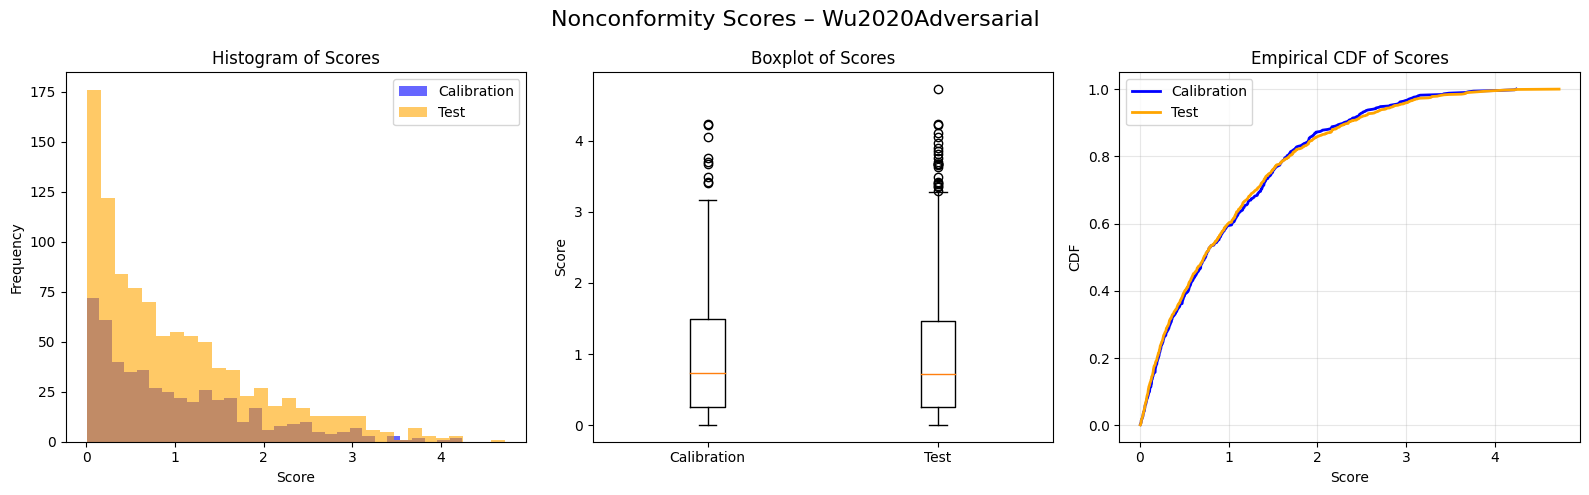

In [50]:
plot_scores_for_all_models(clean_results)

In [51]:
adv_results = extract_scores(
    models,
    cal_X_adv, cal_y,
    test_X_adv, test_y,
    datamode="adv"
)


=== Processing model: Wu2020Adversarial (adv) ===



=== Plotting for model: Wu2020Adversarial ===


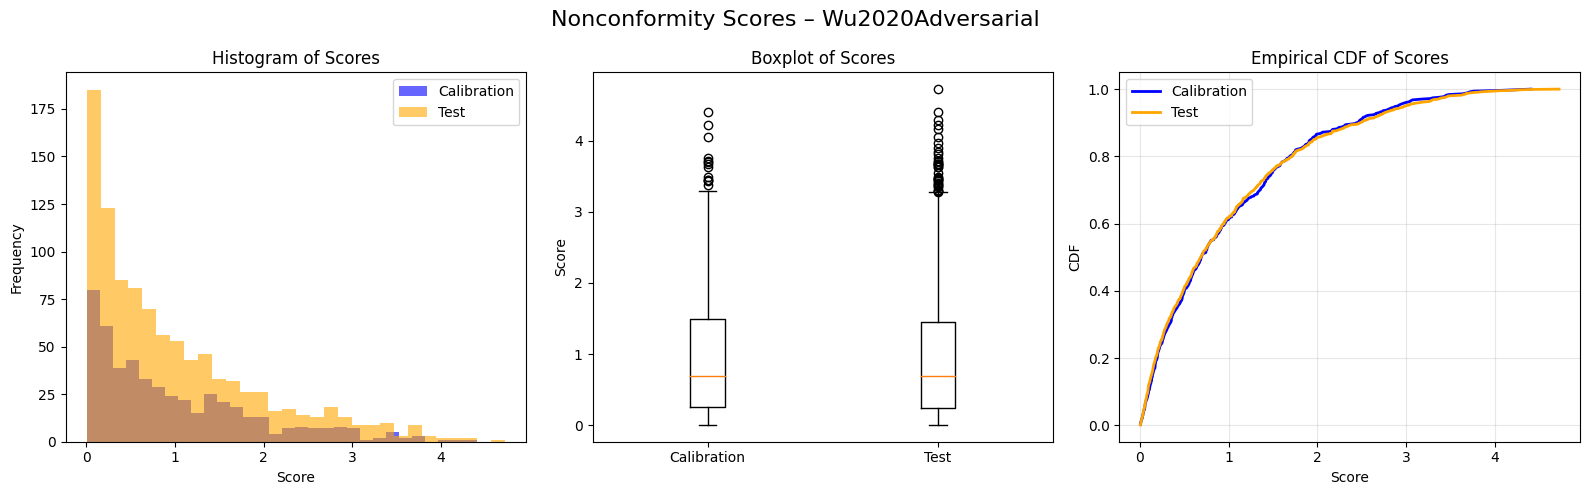

In [52]:
plot_scores_for_all_models(adv_results)

In [54]:
vanilla_cp_test = compute_cp(clean_results, adv_results, alpha=0.1, cal_on='clean', eval_on='clean', interval_on='test' )
adv_cp_test = compute_cp(clean_results, adv_results, alpha=0.1,cal_on='adv', eval_on='adv', interval_on='test')


--- CP for model: Wu2020Adversarial | Cal: clean | Eval: clean | Interval: test ---
 q̂ (CP): 2.298082
 Coverage: 89.50%
 Mean interval width: 0.707887

--- CP for model: Wu2020Adversarial | Cal: adv | Eval: adv | Interval: test ---
 q̂ (CP): 2.442938
 Coverage: 89.60%
 Mean interval width: 0.811592


In [55]:
vanilla_cp_cal = compute_cp(clean_results, adv_results, alpha=0.1, cal_on='clean', eval_on='clean', interval_on='cal' )
adv_cp_cal = compute_cp(clean_results, adv_results, alpha=0.1,cal_on='adv', eval_on='adv', interval_on='cal')



--- CP for model: Wu2020Adversarial | Cal: clean | Eval: clean | Interval: cal ---
 q̂ (CP): 2.298082
 Coverage: 90.00%
 Mean interval width: 0.720152

--- CP for model: Wu2020Adversarial | Cal: adv | Eval: adv | Interval: cal ---
 q̂ (CP): 2.442938
 Coverage: 90.00%
 Mean interval width: 0.827060
